# Advanced Retrieval Evaluation

This notebook evaluates different retrieval strategies using RAGAS and LangSmith metrics.

## Setup and Configuration

In [ ]:
import getpass
import os

import langsmith
from dataloader import load_data
from uuid import uuid4

use_api_keys_input = True # Set to True to use API keys from input

if use_api_keys_input:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")
    os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

    langsmith_project_name = f"AIM - ADVANCED RETRIEVAL COMPARISON - {uuid4().hex[0:8]}"
    os.environ["LANGCHAIN_PROJECT"] = langsmith_project_name


## Import Dependencies


In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI
from retrievers import get_retrieval_chains_and_wrappers
from rag_prompt import get_rag_prompt
from langchain_qdrant import Qdrant
from langchain_experimental.text_splitter import SemanticChunker
from langchain_core.stores import InMemoryStore
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient, models
from langchain_text_splitters import RecursiveCharacterTextSplitter
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.testset import TestsetGenerator
from ragas import EvaluationDataset
from ragas import evaluate as evaluate_ragas, RunConfig
from ragas.metrics import (
    LLMContextPrecisionWithReference,
    LLMContextRecall,
    ContextEntityRecall,
)
from langsmith.evaluation import LangChainStringEvaluator, evaluate as evaluate_langsmith
from langsmith import Client as ClientLangSmith
import numpy as np


/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/pysbd/segmenter.py:66: SyntaxWarning: invalid escape sequence '\s'
  for match in re.finditer('{0}\s*'.format(re.escape(sent)), self.original_text):
/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/pysbd/lang/arabic.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)
/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/pysbd/lang/persian.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)


## Configuration

Set the mode for retrieval strategy. Options:
- `"naive-baseline"`: Standard vector similarity search
- `"semantic"`: Semantic chunking with percentile thresholding

In [3]:
MODE = "naive-baseline"  # semantic


## Load the Data

Load the loan complaint data for evaluation.


In [5]:
loan_complaint_data = load_data(num_docs=50)

loan_complaint_data[0]


Document(metadata={'source': './data/complaints.csv', 'row': 0, 'Date received': '03/27/25', 'Product': 'Student loan', 'Sub-product': 'Federal student loan servicing', 'Issue': 'Dealing with your lender or servicer', 'Sub-issue': 'Trouble with how payments are being handled', 'Consumer complaint narrative': "The federal student loan COVID-19 forbearance program ended in XX/XX/XXXX. However, payments were not re-amortized on my federal student loans currently serviced by Nelnet until very recently. The new payment amount that is effective starting with the XX/XX/XXXX payment will nearly double my payment from {$180.00} per month to {$360.00} per month. I'm fortunate that my current financial position allows me to be able to handle the increased payment amount, but I am sure there are likely many borrowers who are not in the same position. The re-amortization should have occurred once the forbearance ended to reduce the impact to borrowers.", 'Company public response': 'None', 'Company'

## Create Core Components

Initialize the embeddings model, chat model, and RAG prompt template.

In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
chat_model = ChatOpenAI(model="gpt-4.1-nano")
rag_prompt = get_rag_prompt()


## Setup Vector Store Based on Mode

Configure the vector store based on the selected mode - either naive baseline or semantic chunking.

In [7]:
if MODE == "naive-baseline":
    # ===============================
    # Naive Retrieval
    # ===============================

    vectorstore = Qdrant.from_documents(
        loan_complaint_data,
        embeddings,
        location=":memory:",
        collection_name="LoanComplaints"
    )
    
elif MODE == "semantic":
    # ===============================
    # Semantic Retrieval
    # ===============================

    semantic_chunker = SemanticChunker(
        embeddings,
        breakpoint_threshold_type="percentile"
    )
    loan_complaint_data = semantic_chunker.split_documents(loan_complaint_data)
    semantic_vectorstore = Qdrant.from_documents(
        loan_complaint_data,
        embeddings,
        location=":memory:",
        collection_name="Loan_Complaint_Data_Semantic_Chunks"
    )
    vectorstore = semantic_vectorstore
else:
    raise ValueError(f"Invalid mode: {MODE}")


## Create RAGAS Dataset

Generate a golden dataset using RAGAS for evaluation purposes.

In [ ]:
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
golden_dataset = generator.generate_with_langchain_docs(loan_complaint_data, testset_size=50)

# View the dataset
golden_dataset.to_pandas()


Applying SummaryExtractor:   0%|          | 0/31 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/50 [00:00<?, ?it/s]

Node 17deca8b-6f87-461e-9630-b053a9220795 does not have a summary. Skipping filtering.
Node 42d8c277-19f7-4b3e-b27b-bc50074a0242 does not have a summary. Skipping filtering.
Node 3cb7eeab-eeca-4de9-aadb-201175cdee5c does not have a summary. Skipping filtering.
Node 39a1aff0-9583-4041-b8ed-cde69e4a6b7f does not have a summary. Skipping filtering.
Node d5bf3fb3-db4b-42bd-b60b-44ff345285df does not have a summary. Skipping filtering.
Node 2b681509-d2fe-4b4a-8182-3fb938ba30d0 does not have a summary. Skipping filtering.
Node e3d2f161-e641-4d8d-9f5b-8f116b21c96e does not have a summary. Skipping filtering.
Node 80a40dbf-55d0-4f84-b325-b4528c13b4a1 does not have a summary. Skipping filtering.
Node 940c25b2-a60b-4401-90d9-066c608637d7 does not have a summary. Skipping filtering.
Node c0ef0f84-7bd8-4964-adc1-56f60a0a3501 does not have a summary. Skipping filtering.
Node 3aaf426a-4929-44aa-abee-1a4f145a2ae5 does not have a summary. Skipping filtering.
Node c5001e28-7d2f-4d16-b746-e593320b1889 d

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/131 [00:00<?, ?it/s]

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('400 Client Error: Bad Request for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Bad request: invalid \'dotted_order\': dotted_order 3f401a95-1427-4b21-bb57-8aab9c7b3430 has timestamp 2025-07-27 16:44:55.620417 +0000 UTC earlier than parent timestamp 2025-07-27 16:44:59.809401 +0000 UTC for run_id:3f401a95-1427-4b21-bb57-8aab9c7b3430 trace_id:f8d9f996-75a2-4ed7-95b4-8d531f640b7b dotted_order:20250727T164459809401Zf8d9f996-75a2-4ed7-95b4-8d531f640b7b.20250727T164455620417Z3f401a95-1427-4b21-bb57-8aab9c7b3430 parent_run_id:f8d9f996-75a2-4ed7-95b4-8d531f640b7b"}\n')


...

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/50 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,Wher do I find out who my loan servicer is on ...,"[According to Studentaid.gov, Im to get an ema...",Studentaid.gov says that you should get an ema...,single_hop_specifc_query_synthesizer
1,Wut does fedral law say about credit report in...,[I am writing to formally dispute inaccurate i...,"Fedral law, specifcally the Fair Credit Report...",single_hop_specifc_query_synthesizer
2,How can I help someone who has Aid Avantage an...,[I am devastated. I would like to report a sit...,"According to the context, the individual with ...",single_hop_specifc_query_synthesizer
3,Why does EdFinancal only have space for one sk...,[I have provided documentation relating to my ...,EdFinancial's form provides for only one entry...,single_hop_specifc_query_synthesizer
4,Why credit bureaus not take off stuff from my ...,[Breach of Contract - All four branches have v...,I have sent a dispute letter to all 3 other ag...,single_hop_specifc_query_synthesizer
5,Wut shud a consuemer do wen NelNet keeps sayin...,"[I keep setting up auto-debit with NelNet, get...","Accordin to the context, NelNet has sent multi...",single_hop_specifc_query_synthesizer
6,Wut shud I do if XXXX dosnt show my paymints?,[XXXX now has my loan transferred from Navient...,"XXXX is missing $26,000.00 in payments made to...",single_hop_specifc_query_synthesizer
7,How does the abolishment of the U.S. Departmen...,[Illegal Student Loan Reporting & Collections ...,The abolishment of the U.S. Department of Educ...,single_hop_specifc_query_synthesizer
8,Wut is NelNet's responsibilty wen a payment sh...,[XX/XX/XXXX I increased the amount to automati...,"According to the context, when a payment showe...",single_hop_specifc_query_synthesizer
9,what indiana deceptive consumers sales act do,[This account was transferred to Nelnet ( NNI ...,indiana deceptive consumers sales act is a con...,single_hop_specifc_query_synthesizer


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('400 Client Error: Bad Request for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Bad request: invalid \'dotted_order\': dotted_order 69add85c-3517-4ad1-a411-fdaad80b4ff8 has timestamp 2025-07-27 16:53:29.86944 +0000 UTC earlier than parent timestamp 2025-07-27 16:53:35.921731 +0000 UTC for run_id:0d681a22-dfe6-4ddb-bfa2-917e5ec4bf27 trace_id:0ea2bc1c-13e9-4f29-aa66-ddf6ccd83c5c dotted_order:20250727T165335921325Z0ea2bc1c-13e9-4f29-aa66-ddf6ccd83c5c.20250727T165335921731Z830912c4-8db5-45e7-9d85-427d22a92813.20250727T165329869440Z69add85c-3517-4ad1-a411-fdaad80b4ff8.20250727T165329872184Z0d681a22-dfe6-4ddb-bfa2-917e5ec4bf27 parent_run_id:69add85c-3517-4ad1-a411-fdaad80b4ff8"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/

## Setup Parent Document Retrieval

Configure the parent document retrieval strategy with child chunking.

In [10]:
# Create the retriever - parent document retrieval
parent_docs = loan_complaint_data
child_splitter = RecursiveCharacterTextSplitter(chunk_size=750)

client_qdrant = QdrantClient(location=":memory:")
client_qdrant.create_collection(
    collection_name="full_documents",
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

parent_document_vectorstore = QdrantVectorStore(
    collection_name="full_documents", 
    embedding=OpenAIEmbeddings(model="text-embedding-3-small"), 
    client=client_qdrant
)

in_memory_store = InMemoryStore()


## Configure Retrievers

Set up the configuration for different retrieval strategies.

In [11]:
retrievers_config = {
    "naive": {
        "vectorstore": vectorstore
    },
    "parent_document": {
        "vectorstore": parent_document_vectorstore,
        "in_memory_store": in_memory_store,
        "child_splitter": child_splitter
    }
}


## Create RAG Retrievers and Chains

Generate the retrieval chains and wrappers for evaluation.

In [12]:
chains, wrappers = get_retrieval_chains_and_wrappers(
    retrievers_config, 
    loan_complaint_data, 
    rag_prompt, 
    chat_model, 
    MODE
)


## Initialize Evaluation Results Storage

Prepare dictionaries to store evaluation results.

In [13]:
eval_full_results = {}
eval_summary_results = {}
eval_langsmith_raw_results = {}
eval_langsmith_summary_results = {}


## Run RAGAS Evaluation

Evaluate each retrieval strategy using RAGAS metrics for retrieval performance.

In [ ]:
import copy
import pickle
import os
skip_evaluation = []

for chain_name in chains.keys():
    print(f"\n=== Evaluating {chain_name} with RAGAS ===")

    if chain_name in skip_evaluation:
        print(f"Skipping {chain_name} because it is in skip_evaluation list. and already has been evaluated")
        continue

    # Prepare dataset for this chain
    golden_dataset_active_copy = copy.deepcopy(golden_dataset)

    print(f"data type dataset: {type(golden_dataset_active_copy)}")

    # Generate responses for evaluation
    for test_row in golden_dataset_active_copy:
        response = wrappers[chain_name](test_row.eval_sample.user_input)
        test_row.eval_sample.response = response["response"].content
        test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

    evaluation_active_dataset = EvaluationDataset.from_pandas(golden_dataset_active_copy.to_pandas())
    evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

    custom_run_config = RunConfig(timeout=360)

    # Run evaluation using only RETRIEVAL metrics
    print("Running RAGAS evaluation...")
    eval_result_active = evaluate_ragas(
        dataset=evaluation_active_dataset,
        metrics=[LLMContextPrecisionWithReference(), LLMContextRecall(), ContextEntityRecall()],
        llm=evaluator_llm,
        run_config=custom_run_config
    )

    eval_full_results[chain_name] = eval_result_active

    # Convert to DataFrames and compute statistics
    df_eval_result_active = eval_result_active.to_pandas()
    eval_result_active_means = df_eval_result_active.mean(numeric_only=True)
    eval_result_active_stds = df_eval_result_active.std(numeric_only=True)

    eval_summary_results[chain_name] = {
        "means": eval_result_active_means,
        "stds": eval_result_active_stds
    }
    
    print(f"RAGAS Results for {chain_name}:")
    print(eval_result_active_means)
    print(eval_result_active_stds)

    # save results to pickle in case of errors or crashes
    pickle_dict_active_ragas_results = { 
        "raw_results": eval_result_active, 
        "summary_results": eval_summary_results[chain_name] }

    # Save to file
    with open(f"eval_ragas_results_for_{chain_name}.pkl", "wb") as f:
        pickle.dump(pickle_dict_active_ragas_results, f)



=== Evaluating naive_retrieval_chain with RAGAS ===
data type dataset: <class 'ragas.testset.synthesizers.testset_schema.Testset'>
Running RAGAS evaluation...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

Exception raised in Job[44]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 200000, Used 197991, Requested 3055. Please try again in 313ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
Exception raised in Job[52]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 200000, Used 196609, Requested 6179. Please try again in 836ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
Exception raised in Job[70]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 200000,

RAGAS Results for naive_retrieval_chain:
llm_context_precision_with_reference    0.813730
context_recall                          0.986715
context_entity_recall                   0.491178
dtype: float64
llm_context_precision_with_reference    0.210882
context_recall                          0.075163
context_entity_recall                   0.281695
dtype: float64

=== Evaluating bm25_retrieval_chain with RAGAS ===
data type dataset: <class 'ragas.testset.synthesizers.testset_schema.Testset'>
Running RAGAS evaluation...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

RAGAS Results for parent_document_retrieval_chain:
llm_context_precision_with_reference    0.896111
context_recall                          0.930556
context_entity_recall                   0.464714
dtype: float64
llm_context_precision_with_reference    0.257833
context_recall                          0.183078
context_entity_recall                   0.269754
dtype: float64

=== Evaluating ensemble_retrieval_chain with RAGAS ===
data type dataset: <class 'ragas.testset.synthesizers.testset_schema.Testset'>
Running RAGAS evaluation...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

Exception raised in Job[32]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 200000, Used 197007, Requested 6665. Please try again in 1.101s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
Exception raised in Job[53]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 200000, Used 195627, Requested 6594. Please try again in 666ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
Exception raised in Job[43]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 200000

RAGAS Results for ensemble_retrieval_chain:
llm_context_precision_with_reference    0.748444
context_recall                          0.997416
context_entity_recall                   0.476105
dtype: float64
llm_context_precision_with_reference    0.204341
context_recall                          0.016944
context_entity_recall                   0.284641
dtype: float64


## Results Summary

Display comprehensive evaluation results for all retrieval strategies.

In [31]:
print("\n" + "=" * 50)
print("FINAL EVALUATION SUMMARY")
print("=" * 50)

for chain_name in chains.keys():
    print(f"\n--- {chain_name.upper()} ---")
    
    # RAGAS metrics
    print("\nRAGAS Metrics (Mean ± Std):")
    means = eval_summary_results[chain_name]["means"]
    stds = eval_summary_results[chain_name]["stds"]
    
    for metric in means.index:
        print(f"  {metric}: {means[metric]:.3f} ± {stds[metric]:.3f}")
    



FINAL EVALUATION SUMMARY

--- NAIVE_RETRIEVAL_CHAIN ---

RAGAS Metrics (Mean ± Std):
  llm_context_precision_with_reference: 0.814 ± 0.211
  context_recall: 0.987 ± 0.075
  context_entity_recall: 0.491 ± 0.282

--- BM25_RETRIEVAL_CHAIN ---

RAGAS Metrics (Mean ± Std):
  llm_context_precision_with_reference: 0.766 ± 0.347
  context_recall: 0.854 ± 0.309
  context_entity_recall: 0.437 ± 0.305

--- CONTEXTUAL_COMPRESSION_RETRIEVAL_CHAIN ---

RAGAS Metrics (Mean ± Std):
  llm_context_precision_with_reference: 0.937 ± 0.177
  context_recall: 0.960 ± 0.122
  context_entity_recall: 0.510 ± 0.289

--- MULTI_QUERY_RETRIEVAL_CHAIN ---

RAGAS Metrics (Mean ± Std):
  llm_context_precision_with_reference: 0.762 ± 0.231
  context_recall: 0.989 ± 0.054
  context_entity_recall: 0.410 ± 0.272

--- PARENT_DOCUMENT_RETRIEVAL_CHAIN ---

RAGAS Metrics (Mean ± Std):
  llm_context_precision_with_reference: 0.896 ± 0.258
  context_recall: 0.931 ± 0.183
  context_entity_recall: 0.465 ± 0.270

--- ENSEMBLE_RET


Creating heatmap visualization...


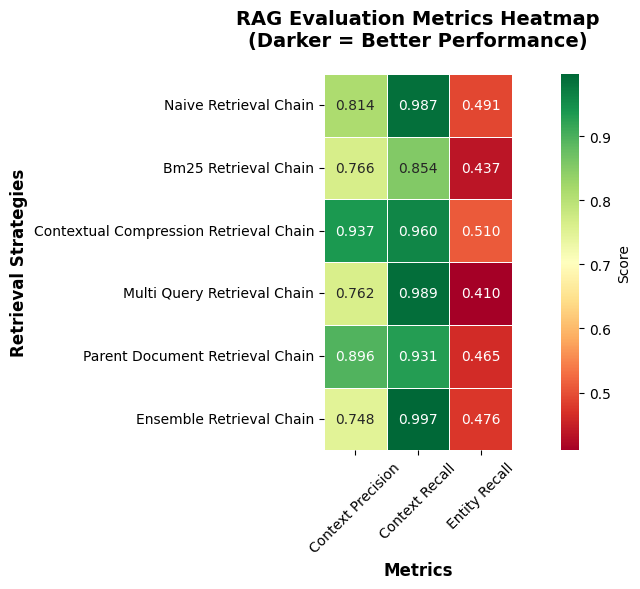

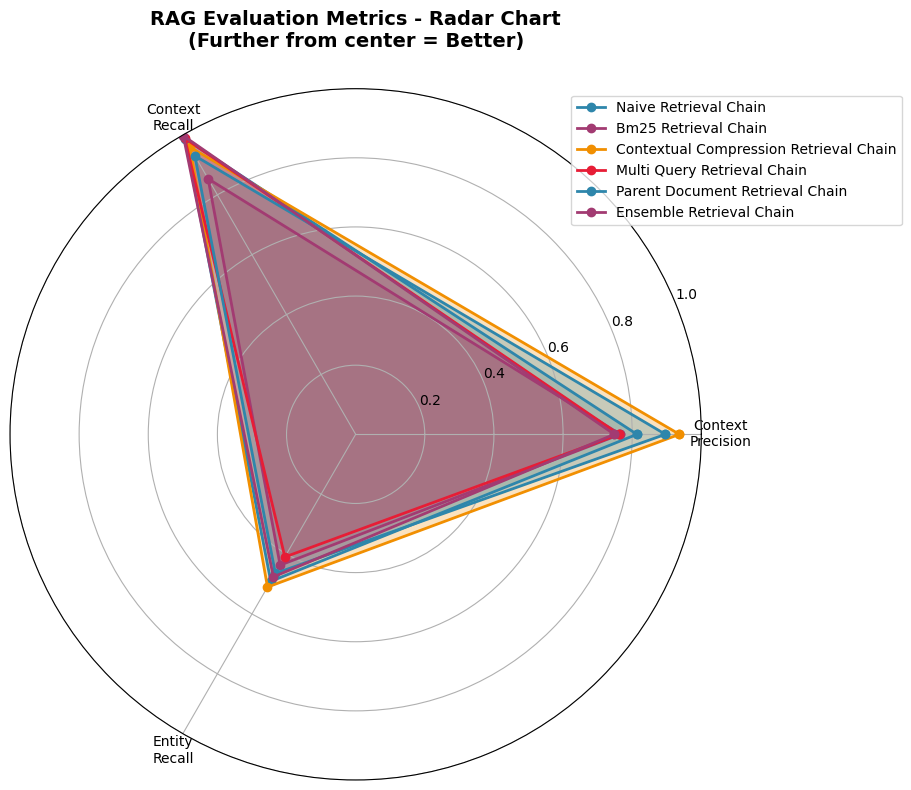

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create heatmap visualization
def create_heatmap_visualization(eval_summary_results):
    """
    Create a heatmap showing metric performance across chains
    """
    # Prepare data for heatmap
    heatmap_data = []
    chains = list(eval_summary_results.keys())
    metrics = ['llm_context_precision_with_reference', 'context_recall', 'context_entity_recall']
    
    for chain in chains:
        means = eval_summary_results[chain]["means"]
        row_data = [means[metric] for metric in metrics]
        heatmap_data.append(row_data)
    
    # Create DataFrame for heatmap
    df_heatmap = pd.DataFrame(
        heatmap_data, 
        index=[chain.replace('_', ' ').title() for chain in chains],
        columns=['Context Precision', 'Context Recall', 'Entity Recall']
    )
    
    # Create the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_heatmap, 
                annot=True, 
                cmap='RdYlGn',
                fmt='.3f',
                linewidths=0.5,
                cbar_kws={'label': 'Score'},
                square=True)
    
    plt.title('RAG Evaluation Metrics Heatmap\n(Darker = Better Performance)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Metrics', fontsize=12, fontweight='bold')
    plt.ylabel('Retrieval Strategies', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return df_heatmap

# Create performance comparison radar chart
def create_radar_chart(eval_summary_results):
    """
    Create a radar chart comparing all metrics across chains
    """
    import numpy as np
    
    chains = list(eval_summary_results.keys())
    metrics = ['llm_context_precision_with_reference', 'context_recall', 'context_entity_recall']
    metric_labels = ['Context\nPrecision', 'Context\nRecall', 'Entity\nRecall']
    
    # Number of metrics
    N = len(metrics)
    
    # Compute angle for each metric
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#E71D36']
    
    for i, chain in enumerate(chains):
        means = eval_summary_results[chain]["means"]
        values = [means[metric] for metric in metrics]
        values += values[:1]  # Complete the circle
        
        ax.plot(angles, values, 'o-', linewidth=2, 
                label=chain.replace('_', ' ').title(), color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.25, color=colors[i % len(colors)])
    
    # Customize the radar chart
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.grid(True)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.title('RAG Evaluation Metrics - Radar Chart\n(Further from center = Better)', 
              fontsize=14, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

# Generate alternative visualizations
print("\nCreating heatmap visualization...")
heatmap_df = create_heatmap_visualization(eval_summary_results)

create_radar_chart(eval_summary_results)

# Cost and Latency Analysis

In [ ]:
from langsmith import Client
from pprint import pprint

client = Client()

retrieval_names = [
              "naive_retrieval_chain",
              "bm25_retrieval_chain",
              "contextual_compression_retrieval_chain",
              "multi_query_retrieval_chain",
              "parent_document_retrieval_chain",
              "ensemble_retrieval_chain"]

cost_and_latency = {}
cost_and_latency_raw = {}
for retriever_name in retrieval_names:

    # Get latest runs
    runs = client.list_runs(
        project_name=langsmith_project_name,
        execution_order=1,
        order_by="start_time",
        limit=50,
        filter=f'eq(name, "RAG {retriever_name} - naive-baseline")',
        order="desc"                         # Most recent first
    )

    #print(f"Total runs: {len(list(runs))}")
    #pprint(next(runs).__dict__.keys())
    #pprint(vars(next(runs)))

    latency_raw_list = []
    cost_raw_list = []
    for run in runs:
        if run.start_time and run.end_time:
            latency = (run.end_time - run.start_time).total_seconds()
            latency_raw_list.append(latency)
        if run.total_cost is not None:
            cost_raw_list.append(run.total_cost)

    cost_and_latency_raw[retriever_name] = {
        "cost_raw": cost_raw_list, 
        "latency_raw": latency_raw_list
    }

    cost_and_latency[retriever_name] = {
        "cost_total": np.array(cost_raw_list).sum(),
        "latency_mean": np.array(latency_raw_list).mean(),
        "latency_std": np.array(latency_raw_list).std()
    }

pprint(cost_and_latency)

{'bm25_retrieval_chain': {'cost_total': Decimal('0.0228987'),
                          'latency_mean': np.float64(3.5382205),
                          'latency_std': np.float64(1.8500556493722913)},
 'contextual_compression_retrieval_chain': {'cost_total': Decimal('0.0181598'),
                                            'latency_mean': np.float64(7.590355680851065),
                                            'latency_std': np.float64(18.05135549538422)},
 'ensemble_retrieval_chain': {'cost_total': np.float64(0.0),
                              'latency_mean': np.float64(nan),
                              'latency_std': np.float64(nan)},
 'multi_query_retrieval_chain': {'cost_total': Decimal('0.0560695'),
                                 'latency_mean': np.float64(6.6234483000000015),
                                 'latency_std': np.float64(2.708579895163946)},
 'naive_retrieval_chain': {'cost_total': Decimal('0.0514892'),
                           'latency_mean': np.float64(10.

/tmp/ipykernel_34191/4083592952.py:49: RuntimeWarning: Mean of empty slice.
  "latency_mean": np.array(latency_raw_list).mean(),
/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/09_Advanced_Retrieval/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encounter

In [ ]:
# Create comparison plots for cost and latency
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
retrievers = list(cost_and_latency.keys())
costs = []
latencies = []
latency_stds = []

for retriever in retrievers:
    cost_total = float(cost_and_latency[retriever]['cost_total'])
    latency_mean = cost_and_latency[retriever]['latency_mean']
    latency_std = cost_and_latency[retriever]['latency_std']
    
    costs.append(cost_total)
    latencies.append(latency_mean)
    latency_stds.append(latency_std)

# Clean retriever names for display
clean_names = [name.replace('_retrieval_chain', '').replace('_', ' ').title() for name in retrievers]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cost Comparison
bars1 = ax1.bar(clean_names, costs, color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('Total Cost Comparison Across Retrievers', fontsize=14, fontweight='bold')
ax1.set_xlabel('Retrieval Strategy', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Cost ($)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on cost bars
for bar, cost in zip(bars1, costs):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
             f'${cost:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Latency Comparison with error bars
# Filter out NaN values for plotting
valid_indices = [i for i, lat in enumerate(latencies) if not np.isnan(lat)]
valid_names = [clean_names[i] for i in valid_indices]
valid_latencies = [latencies[i] for i in valid_indices]
valid_stds = [latency_stds[i] for i in valid_indices]

bars2 = ax2.bar(valid_names, valid_latencies, yerr=valid_stds, 
                color='#3498DB', alpha=0.8, edgecolor='black', linewidth=1,
                capsize=5, error_kw={'linewidth': 2, 'ecolor': 'darkblue'})
ax2.set_title('Average Latency Comparison Across Retrievers', fontsize=14, fontweight='bold')
ax2.set_xlabel('Retrieval Strategy', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Latency (seconds)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on latency bars
for bar, latency, std in zip(bars2, valid_latencies, valid_stds):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + std + 0.2,
             f'{latency:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("COST AND LATENCY SUMMARY")
print("="*60)
for i, retriever in enumerate(retrievers):
    print(f"\n{clean_names[i]}:")
    print(f"  Total Cost: ${costs[i]:.4f}")
    if not np.isnan(latencies[i]):
        print(f"  Avg Latency: {latencies[i]:.2f} ± {latency_stds[i]:.2f} seconds")
    else:
        print(f"  Avg Latency: No data available")

# Find best performers
if costs:
    min_cost_idx = costs.index(min(costs))
    print(f"\n🏆 Most Cost-Effective: {clean_names[min_cost_idx]} (${costs[min_cost_idx]:.4f})")

valid_latencies_with_names = [(lat, name) for lat, name in zip(valid_latencies, valid_names) if not np.isnan(lat)]
if valid_latencies_with_names:
    fastest_latency, fastest_name = min(valid_latencies_with_names)
    print(f"⚡ Fastest Response: {fastest_name} ({fastest_latency:.2f}s)")
